# Analyse Input for Spatial Distribution

Graphs to decide what spacial regions should be picked

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle

from pkg.plots.plot_variable import plot_variable
from pkg.mask.generate_mask import create_feature_mask

In [14]:
input_path = "../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input_ds = xr.open_dataset(input_path)
climatology_ds = xr.open_dataset(climatology_path)

## Weather Map for Selected Variable and Pressure Level

(<Figure size 1000x600 with 2 Axes>,
 <GeoAxes: title={'center': '10m Wind Speed (m/s) — 2022-02-18T10:00'}>)

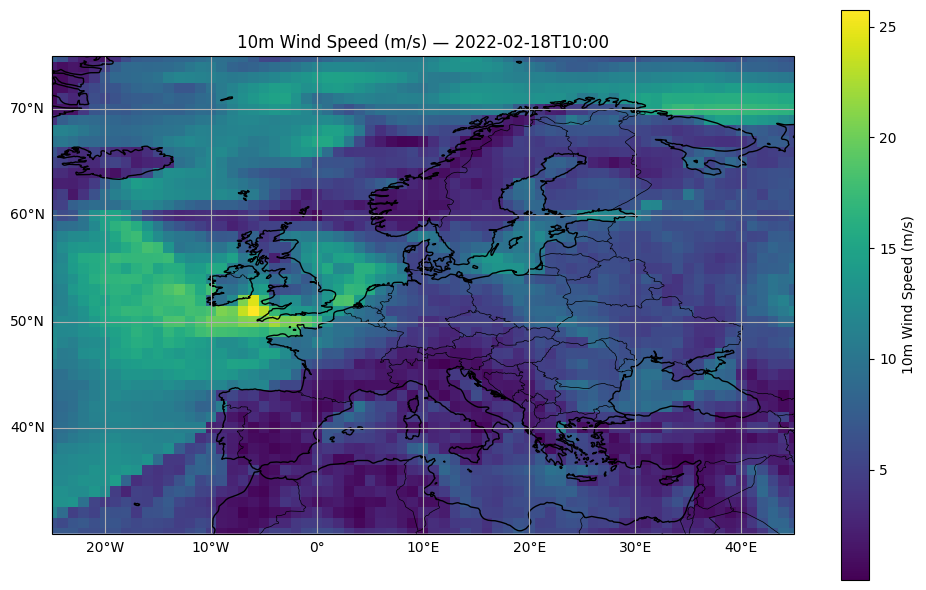

In [15]:
# atmospheric variables: geopotential, temperature, specific_humidity, vertical_velocity,
# u_component_of_wind, v_component_of_wind, wind_speed

# surface variables (level = None): 10m_wind_speed, 2m_temperature, 10m_u_component_of_wind,
# 10m_v_component_of_wind, total_precipitation_6hr, mean_sea_level_pressure

variable = "10m_wind_speed"
level = None  # None for surface variables, 13 for atmospheric variables


# 0 = 10:00 UTC, 1 = 16:00 UTC, 2 (or -1) = 22:00 UTC
time = 0

plot_variable(
    input_ds,
    time=time,
    level=level,
    var_name=variable
)

## Find Exact Position of Storm Core for Selected Times

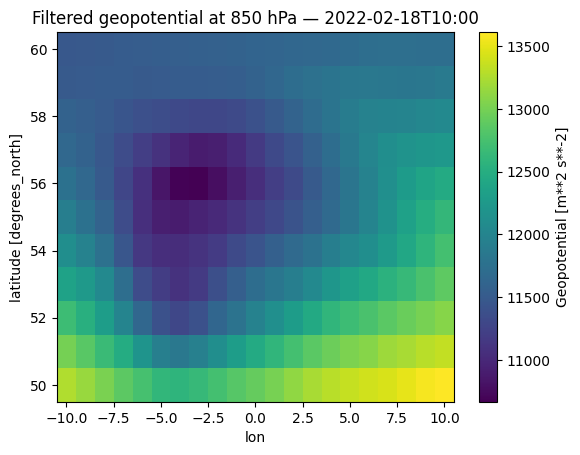

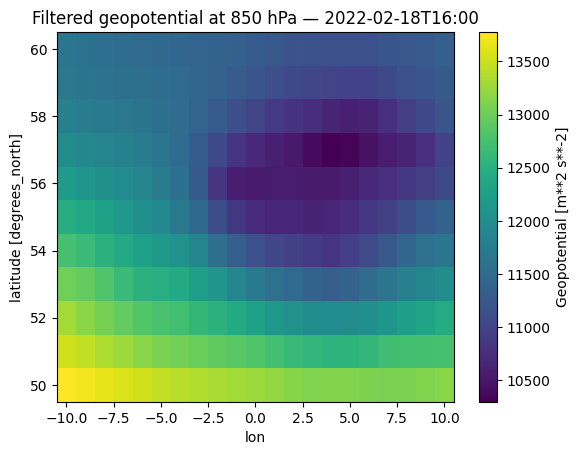

In [16]:
# Time and level settings
times = [0, 1]
time_labels = [str(input_ds.time[t].values)[:16] for t in times]
level = 850  # hPa

storm_centers = {}

for t_idx, label in zip(times, time_labels):
    # Extract geopotential and fix longitude to -180 to 180
    geopot = input_ds["geopotential"].sel(time=ds.time[t_idx], level=level)
    geopot = geopot.assign_coords(lon=(((geopot.lon + 180) % 360) - 180))
    
    # Apply correct slicing AFTER remapping
    geopot = geopot.sortby('lon')  # Very important for proper slicing
    geopot = geopot.where(
        (geopot.lat >= 50) & (geopot.lat <= 60) &
        (geopot.lon >= -10) & (geopot.lon <= 10),
        drop=True
    )
    
    # Optional: plot the filtered data to verify visually
    geopot.plot()
    plt.title(f"Filtered geopotential at 850 hPa — {label}")
    plt.show()
    
    # Get storm center from minimum geopotential
    min_idx = np.unravel_index(np.argmin(geopot.values), geopot.shape)
    lat_min = geopot.isel(lat=min_idx[0], lon=min_idx[1]).lat.item()
    lon_min = geopot.isel(lat=min_idx[0], lon=min_idx[1]).lon.item()

    storm_centers[label] = (lat_min, lon_min)


## Empty Maps

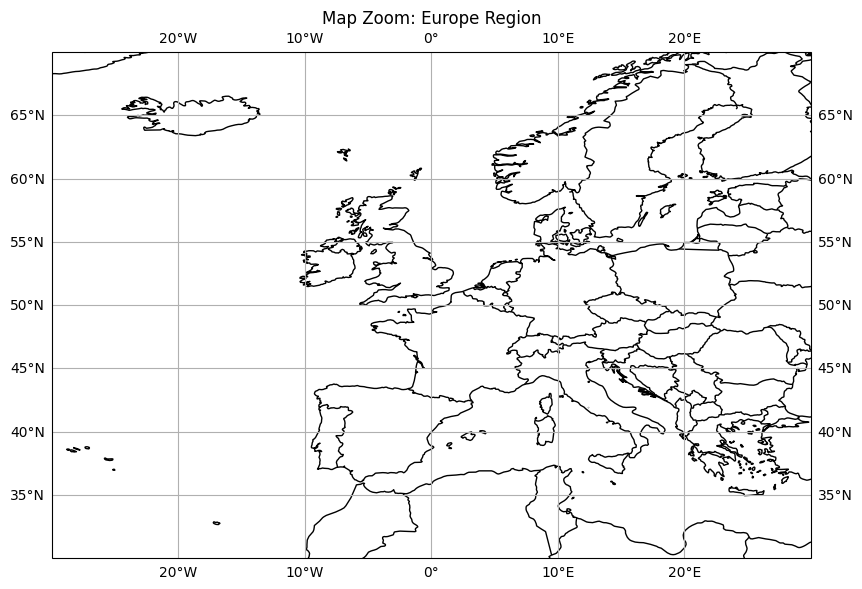

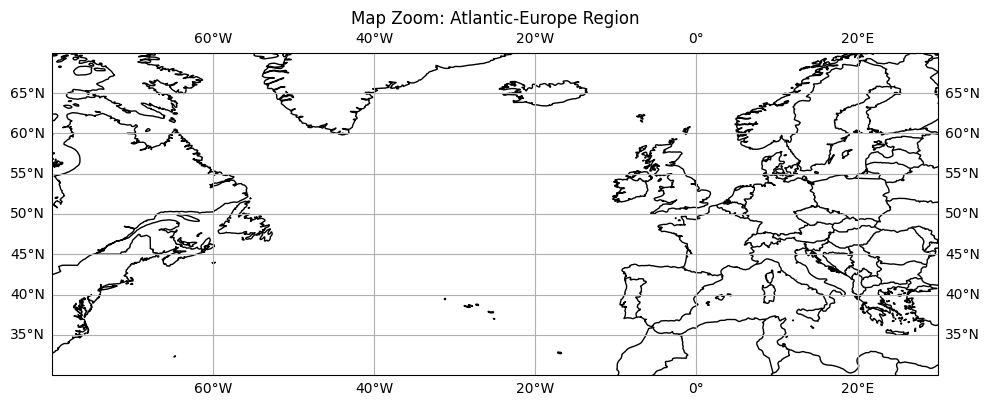

In [17]:
# Define the two zoom extents
zoom_extents = [
    ([-30, 30, 30, 70], "Europe Region"),
    ([-80, 30, 30, 70], "Atlantic-Europe Region")
]

# Generate maps
for extent, title in zoom_extents:
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=True)
    ax.set_title(f"Map Zoom: {title}")
    plt.tight_layout()
    plt.show()


# Masked Regions

In [18]:
mask_storm_core = create_feature_mask(input_ds, regions=["storm_core_10utc", "storm_core_16utc"])
mask_jet_stream = create_feature_mask(input_ds, regions=["dynamic_uljs"])


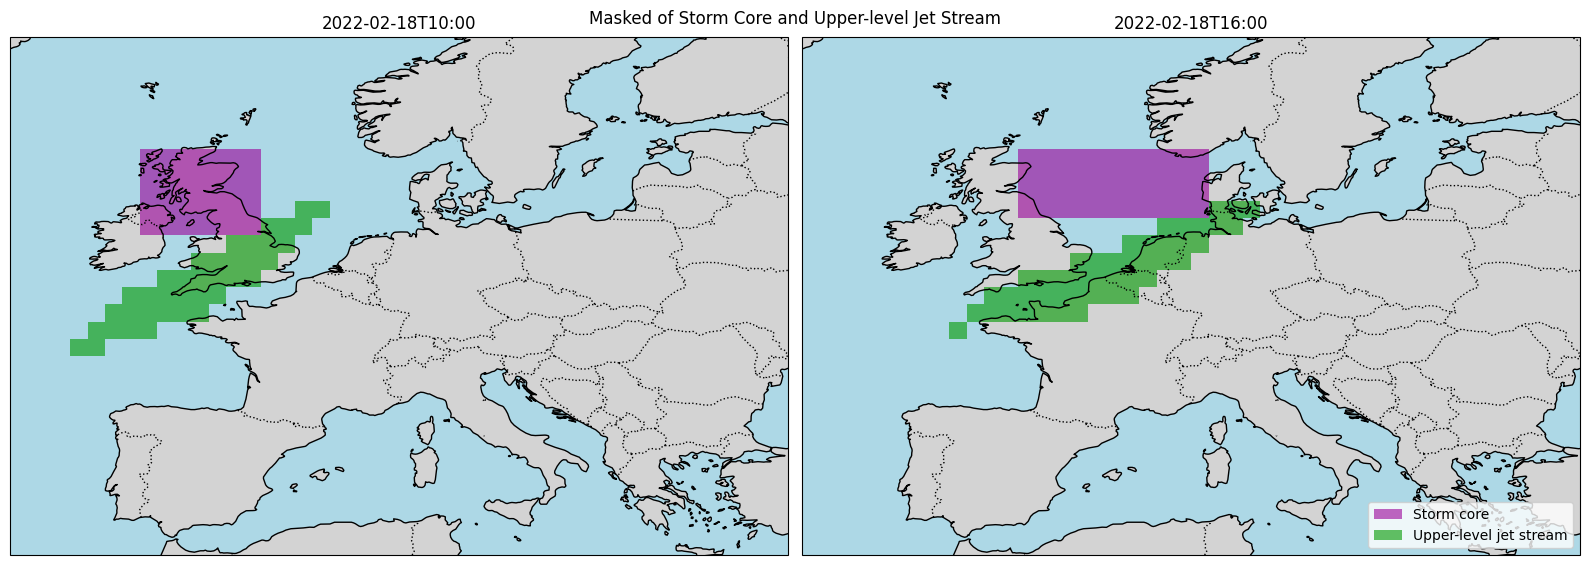

In [19]:
masked_var = "u_component_of_wind"
level_index = 7        # 300 hPa
time_indices = [0, 1]  # t=10:00, t=16:00

# Prepare a 4‐color map: 
#   0→transparent, 1→purple, 2→green, 3→black
cmap = ListedColormap([
    (0,0,0,0),      # 0 = nothing (transparent)
    (0.6, 0, 0.6, 0.6),  # 1 = storm core (semi‐opaque purple)
    (0, 0.6, 0, 0.6),    # 2 = jet stream (semi‐opaque green)
    (0, 0, 0, 0.8),      # 3 = overlap (mostly opaque black)
])
norm = BoundaryNorm([0,1,2,3,4], cmap.N)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16,6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, t_idx in zip(axes, time_indices):
    # extract the two mask layers at this time+level
    storm = mask_storm_core[masked_var] \
                .isel(time=t_idx, level=level_index) \
                .squeeze("batch") \
                .values.astype(int)
    jet   = mask_jet_stream[masked_var] \
                .isel(time=t_idx, level=level_index) \
                .squeeze("batch") \
                .values.astype(int)

    # combined code: 0,1,2,3
    combined = storm + 2*jet

    # plot
    mesh = ax.pcolormesh(
        mask_storm_core.lon, mask_storm_core.lat, combined,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree()
    )

    # add coast/borders/land/ocean
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND,   facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN,  facecolor="lightblue")

    # zoom
    ax.set_extent([-15,30,35,65], ccrs.PlateCarree())
    ax.set_title(f"{str(mask_storm_core.time.values[t_idx])[:16]}")

# build a little legend
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor=cmap(1), label="Storm core"),
    Patch(facecolor=cmap(2), label="Upper-level jet stream"),
]
axes[1].legend(handles=legend_patches, loc="lower right")

plt.suptitle("Masked of Storm Core and Upper-level Jet Stream", y=0.95)
plt.tight_layout()
plt.show()


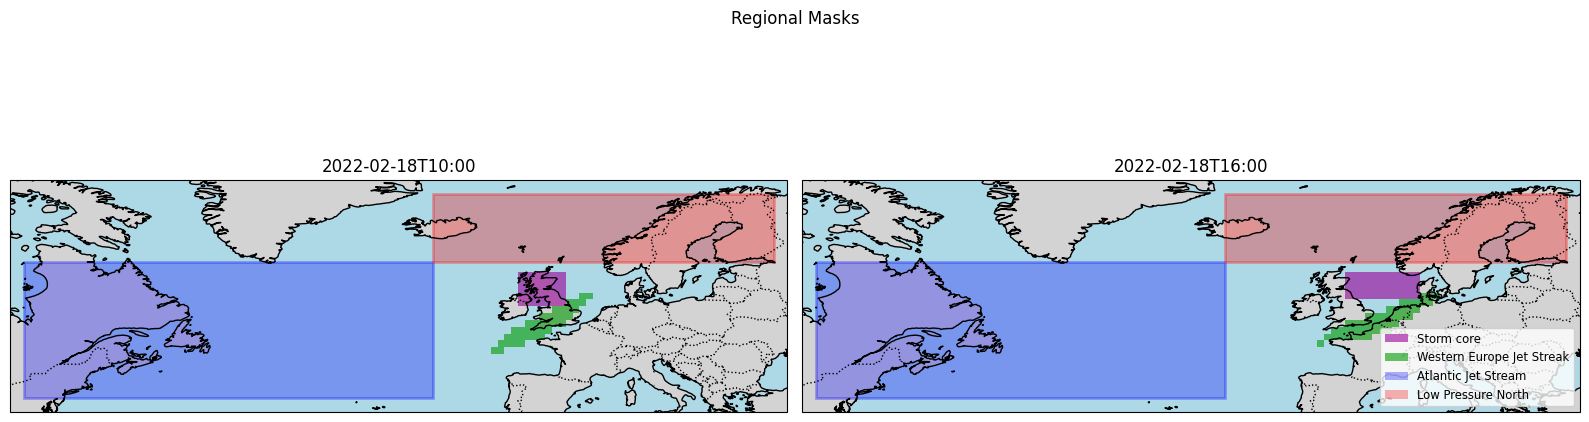

In [20]:
masked_var   = "u_component_of_wind"
level_index  = 7        # 300 hPa
time_indices = [0, 1]   # t=10:00, t=16:00

# bounding boxes for the extra regions
static_boxes = {
    "Atlantic Jet Stream":   (60.0, 280.0, 40.0, 340.0, "blue",   0.3),
    "Low Pressure North":    (70.0, 340.0, 60.0,  30.0, "red",    0.3),
}

fig, axes = plt.subplots(
    1, 2,
    figsize=(16,6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, t_idx in zip(axes, time_indices):
    # 1) plot your combined storm vs jet mask
    storm = mask_storm_core[masked_var] \
                .isel(time=t_idx, level=level_index) \
                .squeeze("batch") \
                .values.astype(int)
    jet   = mask_jet_stream[masked_var] \
                .isel(time=t_idx, level=level_index) \
                .squeeze("batch") \
                .values.astype(int)

    combined = storm + 2*jet

    ax.pcolormesh(
        mask_storm_core.lon, mask_storm_core.lat, combined,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree()
    )

    # 2) add coast/borders/land/ocean
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND,   facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN,  facecolor="lightblue")
    ax.set_extent([-82, 32, 38, 72], ccrs.PlateCarree())
    ax.set_title(str(mask_storm_core.time.values[t_idx])[:16])

    # 3) overlay the three static‐region rectangles
    for label, (N, W, S, E, color, alpha) in static_boxes.items():
        # compute width across the dateline if needed
        if E >= W:
            width = E - W
        else:
            width = (E + 360.0) - W
        height = N - S

        # add rectangle: lower‐left corner at (W,S)
        rect = Rectangle(
            (W, S), width, height,
            edgecolor=color,
            facecolor=color,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            linewidth=2
        )
        ax.add_patch(rect)

# 4) build legend
legend_patches = [
    Patch(facecolor=cmap(1), label="Storm core"),
    Patch(facecolor=cmap(2), label="Western Europe Jet Streak"),
]
for label, (_,_,_,_, color, alpha) in static_boxes.items():
    legend_patches.append(
        Patch(facecolor=color, alpha=alpha, label=label)
    )

axes[1].legend(handles=legend_patches, loc="lower right", fontsize="small")

plt.suptitle("Regional Masks", y=0.95)
plt.tight_layout()
plt.show()

